In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [5]:
from sqlalchemy import create_engine

connection_string = (
    "mssql+pyodbc://MOHAMED-AHMED/ECommerceAnalytics?"
    "driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes&TrustServerCertificate=yes"
)

engine = create_engine(connection_string)

df = pd.read_sql("SELECT * FROM dbo.Sales", engine)

In [6]:
df.head()

,RowID,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,Country,City,...,OrderMonth,OrderMonthName,OrderQuarter,OrderDay,OrderWeekday,ShippingDays,ProfitMargin,HasDiscount,HighProfit,OrderSize
0,1,INDMKB,2020-11-08,2020-11-11,sas,as,asa,asa,asas,asas,...,11,November,4,8,Sunday,3,16.00,False,True,Large
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,asasa,Consumer,United States,Henderson,...,11,November,4,8,Sunday,3,30.00,False,True,Large
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,6,June,2,12,Friday,4,47.00,False,False,Small
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,10,October,4,11,Friday,7,-40.00,True,False,Large
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,10,October,4,11,Friday,7,11.25,True,False,Small


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RowID           9994 non-null   int64  
 1   OrderID         9994 non-null   object 
 2   OrderDate       9994 non-null   object 
 3   ShipDate        9994 non-null   object 
 4   ShipMode        9994 non-null   object 
 5   CustomerID      9994 non-null   object 
 6   CustomerName    9994 non-null   object 
 7   Segment         9994 non-null   object 
 8   Country         9994 non-null   object 
 9   City            9994 non-null   object 
 10  State           9994 non-null   object 
 11  PostalCode      9994 non-null   object 
 12  Region          9994 non-null   object 
 13  ProductID       9994 non-null   object 
 14  Category        9994 non-null   object 
 15  SubCategory     9994 non-null   object 
 16  ProductName     9994 non-null   object 
 17  Sales           9994 non-null   f

In [8]:
df.shape

(9994, 32)

In [9]:
df.columns

Index(['RowID', 'OrderID', 'OrderDate', 'ShipDate', 'ShipMode', 'CustomerID',
       'CustomerName', 'Segment', 'Country', 'City', 'State', 'PostalCode',
       'Region', 'ProductID', 'Category', 'SubCategory', 'ProductName',
       'Sales', 'Quantity', 'Discount', 'Profit', 'OrderYear', 'OrderMonth',
       'OrderMonthName', 'OrderQuarter', 'OrderDay', 'OrderWeekday',
       'ShippingDays', 'ProfitMargin', 'HasDiscount', 'HighProfit',
       'OrderSize'],
      dtype='object')

In [10]:
df["HighProfit"].value_counts()

HighProfit
True     4997
False    4997
Name: count, dtype: int64

In [12]:
df["HighProfit"].value_counts(normalize=True)

HighProfit
True     0.5
False    0.5
Name: proportion, dtype: float64

In [13]:
columns_to_drop = [
    "RowID",
    "OrderID",
    "CustomerName",
    "ProductName",
    "OrderDate",
    "ShipDate",
    "Profit",
    "ProfitMargin",
    "HighProfit"
]

X = df.drop(columns=columns_to_drop)

y = df["HighProfit"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (9994, 23)
Target Shape: (9994,)


In [14]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("-" * 50)

print("Numerical Features:")
print(numerical_features)

Categorical Features:
['ShipMode', 'CustomerID', 'Segment', 'Country', 'City', 'State', 'PostalCode', 'Region', 'ProductID', 'Category', 'SubCategory', 'OrderMonthName', 'OrderWeekday', 'OrderSize']
--------------------------------------------------
Numerical Features:
['Sales', 'Quantity', 'Discount', 'OrderYear', 'OrderMonth', 'OrderQuarter', 'OrderDay', 'ShippingDays', 'HasDiscount']


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (7995, 23)
Test : (1999, 23)


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [18]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_pred = rf_pipeline.predict(X_test)

In [20]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9059529764882441
Precision: 0.8910318225650916
Recall   : 0.924924924924925
F1 Score : 0.9076620825147348


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.92      0.89      0.90      1000
        True       0.89      0.92      0.91       999

    accuracy                           0.91      1999
   macro avg       0.91      0.91      0.91      1999
weighted avg       0.91      0.91      0.91      1999



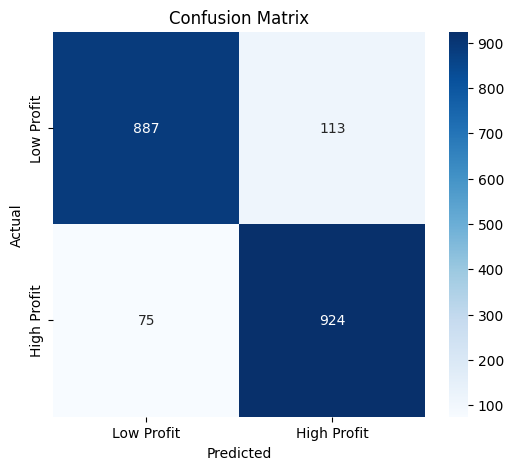

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Profit", "High Profit"],
    yticklabels=["Low Profit", "High Profit"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [25]:
from sklearn.pipeline import Pipeline

results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    predictions = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

c:\Users\Soft Key\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.923962,0.921393,0.926927,0.924152
3,Gradient Boosting,0.916458,0.878871,0.965966,0.920362
2,Random Forest,0.905953,0.891032,0.924925,0.907662
0,Logistic Regression,0.817909,0.820383,0.813814,0.817085


In [27]:
results_df.style\
.background_gradient(cmap="Blues")\
.format({
    "Accuracy":"{:.3f}",
    "Precision":"{:.3f}",
    "Recall":"{:.3f}",
    "F1 Score":"{:.3f}"
})

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.924,0.921,0.927,0.924
3,Gradient Boosting,0.916,0.879,0.966,0.920
2,Random Forest,0.906,0.891,0.925,0.908
0,Logistic Regression,0.818,0.820,0.814,0.817


In [28]:
best_model_name = results_df.iloc[0]["Model"]

print(best_model_name)

Decision Tree


In [29]:
best_model = trained_models[best_model_name]

In [30]:
joblib.dump(best_model, "high_profit_model.pkl")

['high_profit_model.pkl']

In [31]:
predictions = best_model.predict(X_test)

prediction_df = X_test.copy()

prediction_df["Actual"] = y_test.values

prediction_df["Predicted"] = predictions

prediction_df.head()

,ShipMode,CustomerID,Segment,Country,City,State,PostalCode,Region,ProductID,Category,...,OrderMonth,OrderMonthName,OrderQuarter,OrderDay,OrderWeekday,ShippingDays,HasDiscount,OrderSize,Actual,Predicted
1712,Standard Class,JP-15520,Consumer,United States,Houston,Texas,77070.0,Central,OFF-PA-10004405,Office Supplies,...,1,January,1,30,Wednesday,5,True,Small,False,False
6272,First Class,AS-10285,Corporate,United States,Palatine,Illinois,60067.0,Central,TEC-AC-10001284,Technology,...,12,December,4,11,Saturday,1,True,Large,True,True
9463,First Class,JS-16030,Consumer,United States,Columbus,Ohio,43229.0,East,OFF-AR-10003560,Office Supplies,...,2,February,1,27,Tuesday,4,True,Small,False,False
8545,Standard Class,DS-13180,Corporate,United States,Columbus,Georgia,31907.0,South,FUR-FU-10003731,Furniture,...,3,March,1,27,Friday,4,False,Small,True,True
4801,Standard Class,MK-17905,Corporate,United States,Jacksonville,Florida,32216.0,South,OFF-BI-10004002,Office Supplies,...,5,May,2,14,Thursday,5,True,Small,False,False


In [32]:
prediction_df.to_csv(
    "high_profit_predictions.csv",
    index=False
)

In [35]:
if best_model_name == "Decision Tree":

    feature_names = best_model.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    importance = best_model.named_steps[
        "classifier"
    ].feature_importances_

    feature_importance = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance
        })
        .sort_values(by="Importance", ascending=False)
    )

    feature_importance.head(15)

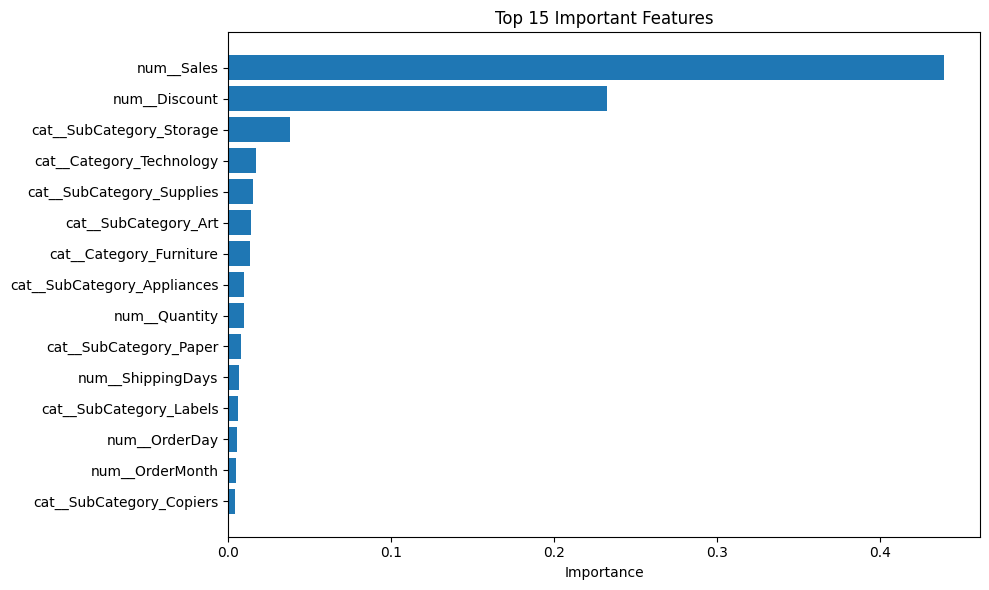

In [36]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()